
# Unit10_Example_Ficks_Laws_Equation | Fick's Laws 質量傳遞方程式之數值模擬 (1D / 2D / 3D)

本 Notebook 針對不可壓縮系統中的 Fick 擴散方程式進行由淺入深的數值模擬，涵蓋三個維度：

## 目標
- **Part 1 (1D)**：以 `py-pde` 求解半無限介質非穩態擴散（erfc 解析解驗證）、有限厚平板雙面擴散（Fourier 級數比對），以及含一階反應的 1D 反應-擴散系統（Thiele 模數與有效因子）
- **Part 2 (2D)**：以 `py-pde` 求解矩形區域 2D 非穩態擴散、圓柱座標軸對稱擴散（`CylindricalSymGrid`），以及 Gray-Scott 雙成分反應-擴散模型（Turing Pattern）
- **Part 3 (3D)**：以 `py-pde` 求解 3D 直角座標箱體非穩態擴散、球形觸媒顆粒的球對稱徑向擴散（`SphericalSymGrid`，與 Crank 解析解比對）
- **Part 4**：多成分擴散延伸討論（Maxwell-Stefan、有效擴散係數、非等莫耳擴散）

**參考講義**：`Unit10_Example_Ficks_Laws_Equation.md`


---
### 0. 環境設定

In [2]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_Ficks_Laws_Equation'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs


---
### 1. 載入套件

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import scipy.special as sp
from scipy.linalg import solve
import scipy
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# py-pde 套件
import pde

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2,
})

print("✓ 套件載入完成")
print(f"  NumPy      : {np.__version__}")
print(f"  scipy      : {scipy.__version__}")
print(f"  matplotlib : {matplotlib.__version__}")
print(f"  py-pde     : {pde.__version__}")


✓ 套件載入完成
  NumPy      : 1.23.5
  scipy      : 1.15.2
  matplotlib : 3.10.8
  py-pde     : 0.51.0


---
## Part 1：一維 (1D) 擴散問題

### 場景一：半無限介質中的非穩態擴散（Semi-infinite Medium）

**問題描述：** 半無限介質（ $x \geq 0$ ），表面 $x=0$ 維持固定濃度 $C_{A0}$ ，初始內部濃度為零。統御方程式為：

$$
\frac{\partial C_A}{\partial t} = D_{AB} \frac{\partial^2 C_A}{\partial x^2}
$$

**解析解（Fick 第二定律）：**

$$
\frac{C_A(x,t)}{C_{A0}} = \mathrm{erfc}\!\left(\frac{x}{2\sqrt{D_{AB} t}}\right)
$$

**界面質量通量：**

$$
N_A(0,t) = C_{A0}\sqrt{\frac{D_{AB}}{\pi t}}
$$

  D_AB=1e-09 m²/s, T=500s → 擴散前緣 ≈ 2.8 mm
✓ Part 1 場景一：求解完成


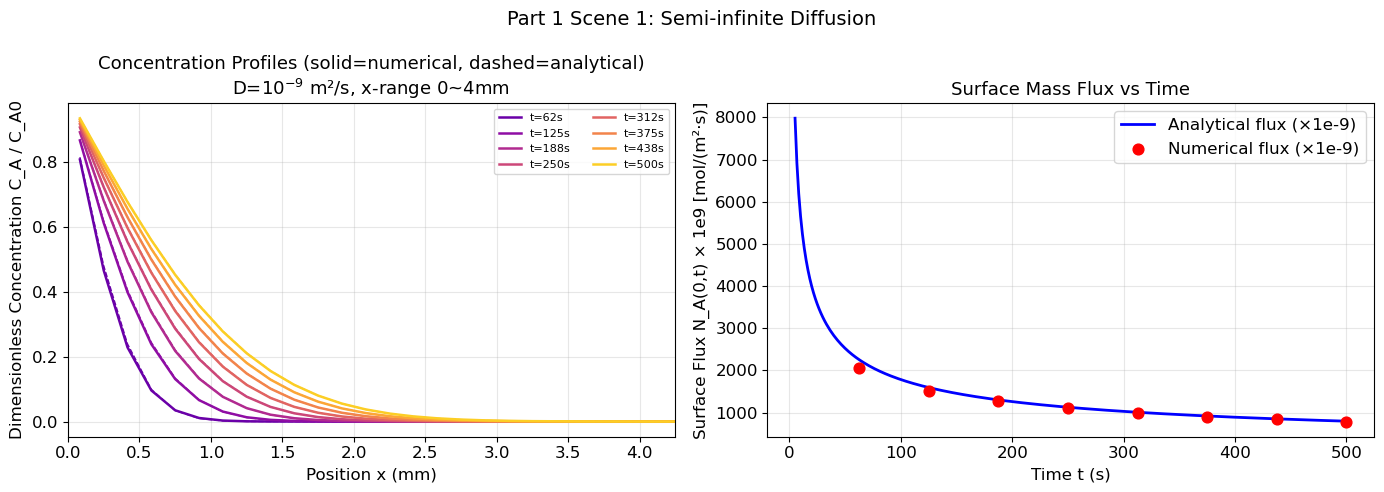

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p1_s1_semi_infinite_diffusion.png


In [20]:
# ============================================================
# Part 1 場景一：半無限介質非穩態擴散 (Semi-infinite Medium)
# ============================================================

# ---- 物理參數 ----
D_AB = 1e-9   # 擴散係數 D_AB (m²/s)，水中小分子典型值
C_A0 = 1.0    # 表面濃度 C_A0 (mol/m³)
L    = 0.05   # 計算域長度 (m) — 截斷的「半無限」長度
T    = 500.0  # 總模擬時間 (s)
N    = 300    # 網格節點數

# 擴散前緣估算：x_front ≈ 4*sqrt(D_AB*T)
x_front_mm = 4 * np.sqrt(D_AB * T) * 1e3
print(f"  D_AB={D_AB:.0e} m²/s, T={T:.0f}s → 擴散前緣 ≈ {x_front_mm:.1f} mm")

# ---- 建立 py-pde 格網與方程式 ----
grid    = pde.CartesianGrid([[0, L]], shape=N)
initial = pde.ScalarField(grid, data=0.0)   # 初始濃度 = 0

# 邊界條件: x=0 → Dirichlet C_A0; x=L → Neumann (zero flux)
bc = [{"value": C_A0}, {"derivative": 0}]
eq = pde.DiffusionPDE(diffusivity=D_AB, bc=bc)

# 儲存快照
storage = pde.MemoryStorage()
result = eq.solve(initial, t_range=T, dt=0.5,
                  tracker=[storage.tracker(T / 8)])

print("✓ Part 1 場景一：求解完成")

# ---- 繪圖：數值解 vs 解析解 (不同時刻) ----
x_arr = grid.axes_coords[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 1 Scene 1: Semi-infinite Diffusion", fontsize=14)

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(storage)))

for i, (t_val, field) in enumerate(storage.items()):
    if t_val == 0:
        continue    # 跳過 t=0 初始條件快照
    C_num = field.data
    C_ana = C_A0 * sp.erfc(x_arr / (2 * np.sqrt(D_AB * t_val + 1e-20)))
    lbl = f"t={t_val:.0f}s"
    axes[0].plot(x_arr * 1e3, C_num / C_A0, color=colors[i], lw=1.8, label=lbl)
    axes[0].plot(x_arr * 1e3, C_ana / C_A0, color=colors[i], lw=1.0, ls='--')

# 縮小 x 軸到擴散前緣附近 (顯示 1.5× 擴散長度)
x_show = min(1.5 * x_front_mm, 25)  # 最大顯示 25mm
axes[0].set_xlim([0, x_show])
axes[0].set_xlabel("Position x (mm)")
axes[0].set_ylabel("Dimensionless Concentration C_A / C_A0")
axes[0].set_title(f"Concentration Profiles (solid=numerical, dashed=analytical)\n"
                  f"D=$10^{{-9}}$ m²/s, x-range 0~{x_show:.0f}mm")
axes[0].legend(fontsize=8, ncol=2)

# 子圖 2：界面通量 vs 時間
t_arr  = np.linspace(5, T, 300)
flux_ana = C_A0 * np.sqrt(D_AB / (np.pi * t_arr))
axes[1].plot(t_arr, flux_ana * 1e9, 'b-', lw=2, label="Analytical flux (×1e-9)")
# 數值界面通量 (有限差分近似)
t_list, flux_num = [], []
for t_val, field in storage.items():
    if t_val == 0:
        continue
    dC_dx0 = (field.data[1] - field.data[0]) / (x_arr[1] - x_arr[0])
    flux_num.append(-D_AB * dC_dx0)
    t_list.append(t_val)
axes[1].scatter(t_list, np.array(flux_num) * 1e9, color='red', zorder=5,
                label="Numerical flux (×1e-9)", marker='o', s=60)
axes[1].set_xlabel("Time t (s)")
axes[1].set_ylabel("Surface Flux N_A(0,t) × 1e9 [mol/(m²·s)]")
axes[1].set_title("Surface Mass Flux vs Time")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "p1_s1_semi_infinite_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p1_s1_semi_infinite_diffusion.png'}")


---
### 場景二：有限厚平板之雙面擴散（Finite Slab Symmetric Diffusion）

**問題描述：** 厚度 $2L$ 的平板，初始均勻濃度 $C_{A,i}$ ，兩端對稱施加表面濃度 $C_{A0}$ 。利用**對稱性**取半板 $x \in [0, L]$ 求解。

**Fourier 級數解（無因次形式， $\theta = (C_A - C_{A0}) / (C_{A,i} - C_{A0})$ ）：**

$$
\theta(\xi, Fo) = \sum_{n=0}^{\infty} \frac{4(-1)^n}{(2n+1)\pi} \cos\!\left(\frac{(2n+1)\pi\xi}{2}\right) \exp\!\left(-\frac{(2n+1)^2\pi^2}{4} Fo\right)
$$

**平均無因次濃度：**

$$
\bar{\theta}(Fo) = \sum_{n=0}^{\infty} \frac{8}{(2n+1)^2\pi^2} \exp\!\left(-\frac{(2n+1)^2\pi^2}{4} Fo\right)
$$

  N_slab=200, dx=0.05 mm, dt_stable=2.0 s
✓ Part 1 場景二：有限平板求解完成  (9 snapshots)


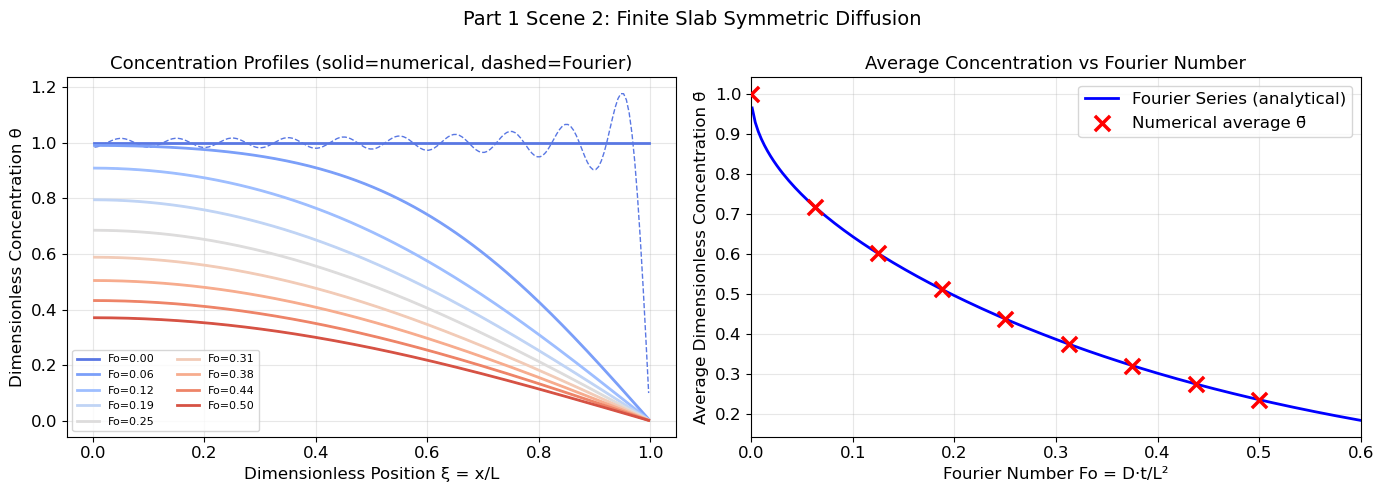

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p1_s2_finite_slab_diffusion.png


In [28]:
# ============================================================
# Part 1 場景二：有限厚平板雙面擴散 (Finite Slab)
# ============================================================

# ---- 物理參數 ----
D_slab = 5e-10   # 擴散係數 (m²/s)
L_slab = 0.01    # 半板厚度 L (m) → 全板厚度 2L = 20 mm
C_Ai   = 1.0     # 初始濃度 (mol/m³)
C_A0s  = 0.0     # 表面濃度 (mol/m³)
T_slab = 1e5     # 總模擬時間 (s)
N_slab = 200

# ---- Fourier 級數解析解 ----
def fourier_slab(xi, Fo, n_terms=20):
    """計算有限平板的 Fourier 級數解 theta(xi, Fo)"""
    theta = np.zeros_like(xi)
    for n in range(n_terms):
        coef = 4 * (-1)**n / ((2*n+1) * np.pi)
        cos_term = np.cos((2*n+1) * np.pi * xi / 2)
        exp_term = np.exp(-((2*n+1)**2 * np.pi**2 / 4) * Fo)
        theta += coef * cos_term * exp_term
    return theta

def fourier_avg_theta(Fo, n_terms=20):
    """計算有限平板平均無因次濃度 theta_bar(Fo)"""
    theta_bar = np.zeros_like(Fo)
    for n in range(n_terms):
        coef = 8 / ((2*n+1)**2 * np.pi**2)
        exp_term = np.exp(-((2*n+1)**2 * np.pi**2 / 4) * Fo)
        theta_bar += coef * exp_term
    return theta_bar

# ---- py-pde 數值解 ----
grid_s  = pde.CartesianGrid([[0, L_slab]], shape=N_slab)
ic_slab = pde.ScalarField(grid_s, data=C_Ai)

# 邊界: x=0 對稱 (Neumann zero); x=L 表面濃度 C_A0
bc_slab = [{"derivative": 0}, {"value": C_A0s}]
eq_slab = pde.DiffusionPDE(diffusivity=D_slab, bc=bc_slab)
storage_s = pde.MemoryStorage()

# CFL 穩定時步: dt ≤ 0.4 * dx² / D
dx_slab  = L_slab / N_slab
dt_slab  = 0.4 * dx_slab**2 / D_slab   # ≈ 2.0 s
print(f"  N_slab={N_slab}, dx={dx_slab*1e3:.2f} mm, dt_stable={dt_slab:.1f} s")

result_s = eq_slab.solve(ic_slab, t_range=T_slab, dt=dt_slab,
                          tracker=[storage_s.tracker(T_slab / 8)])

print(f"✓ Part 1 場景二：有限平板求解完成  ({len(storage_s)} snapshots)")

# ---- 繪圖 ----
x_s = grid_s.axes_coords[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 1 Scene 2: Finite Slab Symmetric Diffusion", fontsize=14)

colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(storage_s)))
xi_arr = x_s / L_slab

for i, (t_val, field) in enumerate(storage_s.items()):
    Fo_val = D_slab * t_val / L_slab**2
    theta_num = (field.data - C_A0s) / (C_Ai - C_A0s)
    theta_ana = fourier_slab(xi_arr, Fo_val)
    axes[0].plot(xi_arr, theta_num, color=colors[i], lw=2,
                 label=f"Fo={Fo_val:.2f}")
    axes[0].plot(xi_arr, theta_ana, color=colors[i], lw=1, ls='--')

axes[0].set_xlabel("Dimensionless Position ξ = x/L")
axes[0].set_ylabel("Dimensionless Concentration θ")
axes[0].set_title("Concentration Profiles (solid=numerical, dashed=Fourier)")
axes[0].legend(fontsize=8, ncol=2)

# 子圖 2：平均濃度隨 Fo 的演變
Fo_num_list, theta_bar_num_list = [], []
for t_val, field in storage_s.items():
    Fo_val = D_slab * t_val / L_slab**2
    theta_num_avg = np.mean((field.data - C_A0s) / (C_Ai - C_A0s))
    Fo_num_list.append(Fo_val)
    theta_bar_num_list.append(theta_num_avg)

# 解析曲線（x 軸範圍與模擬資料對齊）
Fo_max_sim = D_slab * T_slab / L_slab**2          # = 0.5
Fo_range = np.linspace(0.001, Fo_max_sim * 1.2, 200)
theta_bar_ana = fourier_avg_theta(Fo_range)
axes[1].plot(Fo_range, theta_bar_ana, 'b-', lw=2, label="Fourier Series (analytical)")

# × 標記：即使與解析曲線重疊也清晰可見
axes[1].scatter(Fo_num_list, theta_bar_num_list,
                marker='x', color='red', s=120, linewidths=2.5,
                zorder=9, label="Numerical average θ̄")
axes[1].set_xlim(0, Fo_max_sim * 1.2)
axes[1].set_xlabel("Fourier Number Fo = D·t/L²")
axes[1].set_ylabel("Average Dimensionless Concentration θ̄")
axes[1].set_title("Average Concentration vs Fourier Number")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "p1_s2_finite_slab_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p1_s2_finite_slab_diffusion.png'}")

---
### 場景三：1D 反應-擴散系統（Diffusion with First-Order Reaction）

**統御方程式：**

$$
\frac{\partial C_A}{\partial t} = D_{AB} \frac{\partial^2 C_A}{\partial x^2} - k_1 C_A
$$

**穩態解析解（平板幾何）：**

$$
\frac{C_A(x)}{C_{A0}} = \frac{\cosh(\phi \xi)}{\cosh(\phi)}, \quad \phi = L\sqrt{\frac{k_1}{D_{AB}}}
$$

**有效因子：**

$$
\eta = \frac{\tanh(\phi)}{\phi}
$$

本場景探討不同 Thiele 模數 $\phi$ 下，穩態濃度分布形狀的差異，並計算有效因子與 $\phi$ 的關係曲線。

  dx=100.0 μm, dt_diff (CFL) = 2.00 s


  0%|          | 0/183999.3367007505 [00:00<?, ?it/s]

  0%|          | 0/144200.21957100046 [00:00<?, ?it/s]

  0%|          | 0/43601.85848806889 [00:00<?, ?it/s]

  0%|          | 0/12998.018730110158 [00:00<?, ?it/s]

  0%|          | 0/5000.0 [00:00<?, ?it/s]

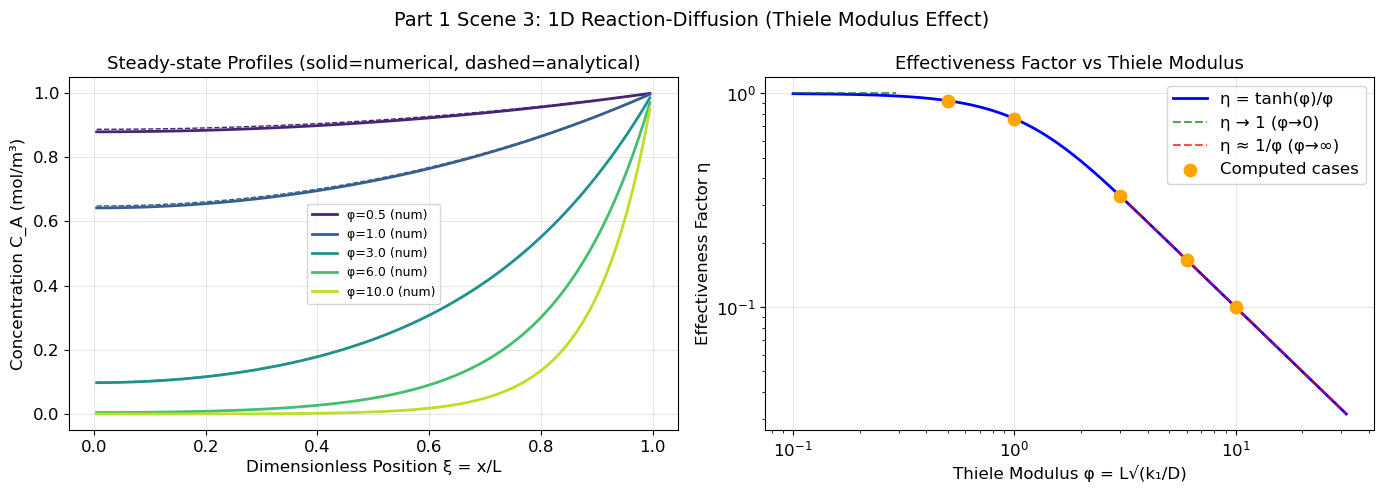


有效因子計算結果：
       φ |       η (解析) | 說明
---------------------------------------------
     0.5 |       0.9242 | 過渡區
     1.0 |       0.7616 | 過渡區
     3.0 |       0.3317 | 擴散強烈限制
     6.0 |       0.1667 | 擴散強烈限制
    10.0 |       0.1000 | 擴散強烈限制

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p1_s3_reaction_diffusion.png


In [22]:
# ============================================================
# Part 1 場景三：1D 反應-擴散系統 (Reaction-Diffusion)
# ============================================================

# ---- 物理參數 ----
D_rxn = 1e-9    # 擴散係數 (m²/s)
L_rxn = 0.01    # 特徵長度 (m)
C_A0r = 1.0     # 表面濃度 (mol/m³)
N_rxn = 100     # 網格節點數（100 節點已足夠精度）

phi_list = [0.5, 1.0, 3.0, 6.0, 10.0]   # 不同 Thiele 模數

# ---- CFL 穩定時步（擴散顯式求解器）----
dx_rxn  = L_rxn / N_rxn
dt_diff = 0.4 * dx_rxn**2 / (2 * D_rxn)   # 純擴散 CFL: dt ≤ dx²/(2D)
print(f"  dx={dx_rxn*1e6:.1f} μm, dt_diff (CFL) = {dt_diff:.2f} s")

# ---- 解析解函數 ----
def steadystate_analytical(xi, phi):
    return np.cosh(phi * xi) / np.cosh(phi)

def effectiveness_factor(phi):
    return np.tanh(phi) / phi

# ---- 繪圖設定 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 1 Scene 3: 1D Reaction-Diffusion (Thiele Modulus Effect)", fontsize=14)

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(phi_list)))
grid_r = pde.CartesianGrid([[0, L_rxn]], shape=N_rxn)
x_r    = grid_r.axes_coords[0]
xi_r   = x_r / L_rxn

for i, phi in enumerate(phi_list):
    k1 = phi**2 * D_rxn / L_rxn**2   # 由 phi 反算 k1

    # 自適應時步：min(CFL_diffusion, CFL_reaction)
    dt_rxn_i = min(dt_diff, 0.4 / k1)

    # 自適應模擬時間：5 個時間常數以達穩態
    # λ₀ = D·π²/(4L²) + k1，τ = 1/λ₀
    lam0    = D_rxn * np.pi**2 / (4 * L_rxn**2) + k1
    T_phi_i = max(5.0 / lam0, 5000.0)

    # 初始條件：IC=0（模擬從無溶質到穩態）
    ic_rxn = pde.ScalarField(grid_r, data=0.0)

    # py-pde PDE（含一階不可逆消耗反應：dc/dt = D∇²c - k₁c）
    eq_rxn = pde.PDE({"c": f"{D_rxn} * laplace(c) - {k1} * c"},
                     bc=[{"derivative": 0}, {"value": C_A0r}])

    result_r = eq_rxn.solve(ic_rxn, t_range=T_phi_i, dt=dt_rxn_i)
    C_num_ss = result_r.data
    C_ana_ss = C_A0r * steadystate_analytical(xi_r, phi)

    axes[0].plot(xi_r, C_num_ss, color=colors[i], lw=2,
                 label=f"φ={phi:.1f} (num)")
    axes[0].plot(xi_r, C_ana_ss, color=colors[i], lw=1, ls='--')

axes[0].set_xlabel("Dimensionless Position ξ = x/L")
axes[0].set_ylabel("Concentration C_A (mol/m³)")
axes[0].set_title("Steady-state Profiles (solid=numerical, dashed=analytical)")
axes[0].legend(fontsize=9)

# 子圖 2：有效因子 η vs Thiele 模數 φ
phi_arr = np.logspace(-1, 1.5, 200)
eta_arr = effectiveness_factor(phi_arr)
axes[1].loglog(phi_arr, eta_arr, 'b-', lw=2, label="η = tanh(φ)/φ")
axes[1].loglog(phi_arr[phi_arr <= 0.3], np.ones(np.sum(phi_arr <= 0.3)),
               'g--', lw=1.5, alpha=0.7, label="η → 1 (φ→0)")
axes[1].loglog(phi_arr[phi_arr >= 3], 1 / phi_arr[phi_arr >= 3],
               'r--', lw=1.5, alpha=0.7, label="η ≈ 1/φ (φ→∞)")
axes[1].scatter(phi_list, [effectiveness_factor(p) for p in phi_list],
                color='orange', s=80, zorder=5, label="Computed cases")
axes[1].set_xlabel("Thiele Modulus φ = L√(k₁/D)")
axes[1].set_ylabel("Effectiveness Factor η")
axes[1].set_title("Effectiveness Factor vs Thiele Modulus")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "p1_s3_reaction_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- 列印有效因子計算結果 ----
print("\n有效因子計算結果：")
print(f"{'φ':>8} | {'η (解析)':>12} | {'說明':}")
print("-" * 45)
for phi in phi_list:
    eta = effectiveness_factor(phi)
    remark = "擴散阻力可忽略" if phi < 0.5 else ("過渡區" if phi < 3 else "擴散強烈限制")
    print(f"  {phi:6.1f} | {eta:12.4f} | {remark}")

print(f"\n✓ 圖檔已儲存：{FIG_DIR / 'p1_s3_reaction_diffusion.png'}")


---
## Part 2：二維 (2D) 擴散問題

### 場景一：矩形區域內的 2D 非穩態擴散

**統御方程式：**

$$
\frac{\partial C_A}{\partial t} = D_{AB} \left(\frac{\partial^2 C_A}{\partial x^2} + \frac{\partial^2 C_A}{\partial y^2}\right)
$$

**混合邊界條件（示例）：** 左邊 $x=0$ 施加固定濃度 $C_{A0}=1$ ，其餘邊施加零濃度或無通量條件。

py-pde 可直接處理 2D CartesianGrid，無需手動離散 2D Laplacian。

✓ Part 2 場景一：2D 矩形擴散求解完成


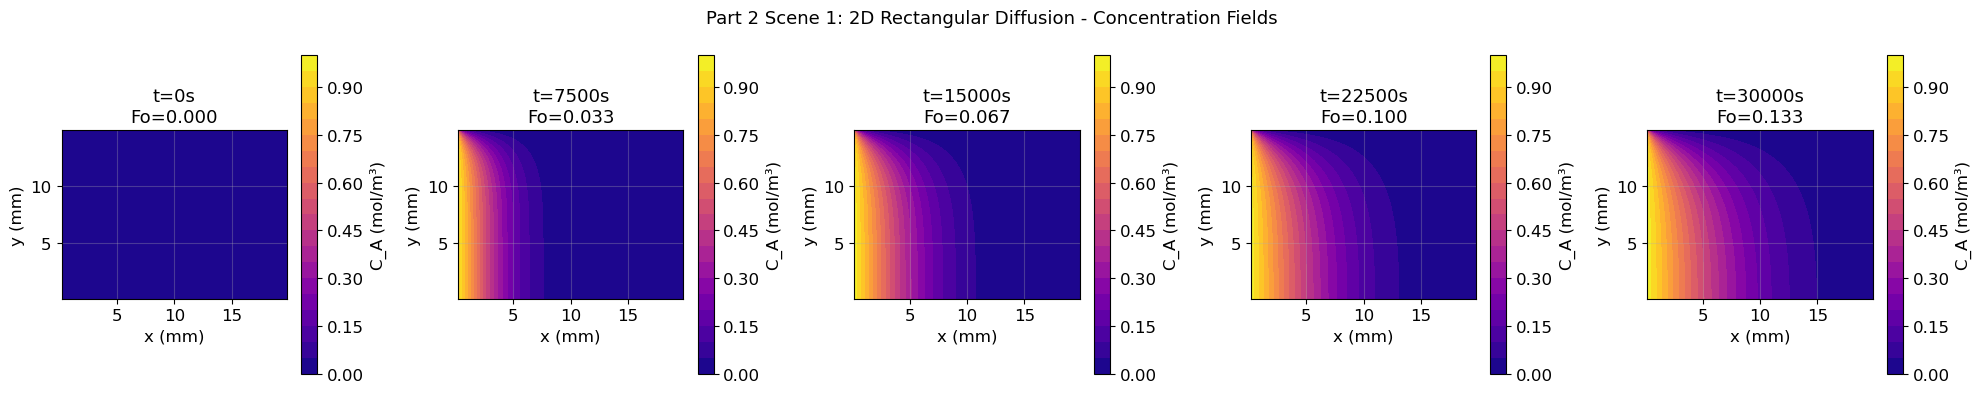

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p2_s1_2d_rectangular_diffusion.png


In [29]:
# ============================================================
# Part 2 場景一：矩形區域 2D 非穩態擴散
# ============================================================

# ---- 物理參數 ----
D_2d = 1e-9   # 擴散係數 (m²/s)
Lx   = 0.02   # x 方向長度 (m)
Ly   = 0.015  # y 方向長度 (m)
T_2d = 3e4    # 總模擬時間 (s)
Nx, Ny = 60, 45

# ---- py-pde 2D 求解 ----
grid_2d = pde.CartesianGrid([[0, Lx], [0, Ly]], shape=[Nx, Ny])

# 初始條件：均勻零濃度
ic_2d = pde.ScalarField(grid_2d, data=0.0)

# 邊界條件: x=0 (左) C=1; x=Lx (右) C=0; y=0 (下) 無通量; y=Ly (上) C=0
# py-pde 邊界條件格式: 每個方向兩端的邊界條件 [[左,右], [下,上]]
bc_2d = [
    [{"value": 1.0}, {"value": 0.0}],    # x 方向
    [{"derivative": 0}, {"value": 0.0}]   # y 方向
]
eq_2d = pde.DiffusionPDE(diffusivity=D_2d, bc=bc_2d)

# 儲存 4 個快照
storage_2d = pde.MemoryStorage()
result_2d = eq_2d.solve(ic_2d, t_range=T_2d, dt=20,
                         tracker=[storage_2d.tracker(T_2d / 4)])

print("✓ Part 2 場景一：2D 矩形擴散求解完成")

# ---- 繪圖：不同時刻的 2D 濃度場 ----
snapshots = list(storage_2d.items())
n_shots = len(snapshots)

fig, axes = plt.subplots(1, n_shots, figsize=(4 * n_shots, 4))
fig.suptitle("Part 2 Scene 1: 2D Rectangular Diffusion - Concentration Fields", fontsize=13)

x_2d = grid_2d.axes_coords[0] * 1e3  # mm
y_2d = grid_2d.axes_coords[1] * 1e3  # mm
X2d, Y2d = np.meshgrid(x_2d, y_2d)

vmin_2d, vmax_2d = 0.0, 1.0   # 固定 colorbar 範圍
levels_2d = np.linspace(vmin_2d, vmax_2d, 21)

for i, (t_val, field) in enumerate(snapshots):
    Fo_2d = D_2d * t_val / (min(Lx, Ly)**2)
    C_data = field.data.T  # (Nx, Ny) → 轉置以符合 (y, x) 繪圖方向
    cf = axes[i].contourf(X2d, Y2d, C_data, levels=levels_2d, cmap='plasma',
                          vmin=vmin_2d, vmax=vmax_2d)
    plt.colorbar(cf, ax=axes[i], label="C_A (mol/m³)")
    axes[i].set_xlabel("x (mm)")
    axes[i].set_ylabel("y (mm)")
    axes[i].set_title(f"t={t_val:.0f}s\nFo={Fo_2d:.3f}")
    axes[i].set_aspect('equal')

plt.tight_layout()
fig.savefig(FIG_DIR / "p2_s1_2d_rectangular_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p2_s1_2d_rectangular_diffusion.png'}")


---
### 場景二：圓柱座標 2D 軸對稱擴散（Cylindrical Symmetric Diffusion）

**問題描述：** 有限長圓柱體（半徑 $R$ 、半長 $H$ ），外表面維持固定濃度 $C_{A0}$ ，內部初始無溶質。

**統御方程式（ $(r,z)$ 平面，軸對稱）：**

$$
\frac{\partial C_A}{\partial t} = D_{AB} \left[\frac{1}{r}\frac{\partial}{\partial r}\!\left(r \frac{\partial C_A}{\partial r}\right) + \frac{\partial^2 C_A}{\partial z^2}\right]
$$

`py-pde` 的 `CylindricalSymGrid` 自動處理圓柱座標的 Laplacian（含 $1/r$ 奇點），軸心 $r=0$ 的對稱邊界由套件內部處理，無需手動設定。


  dr=0.17 mm, dz=0.33 mm, dt_stable=5.6 s
✓ Part 2 場景二：圓柱座標軸對稱擴散求解完成


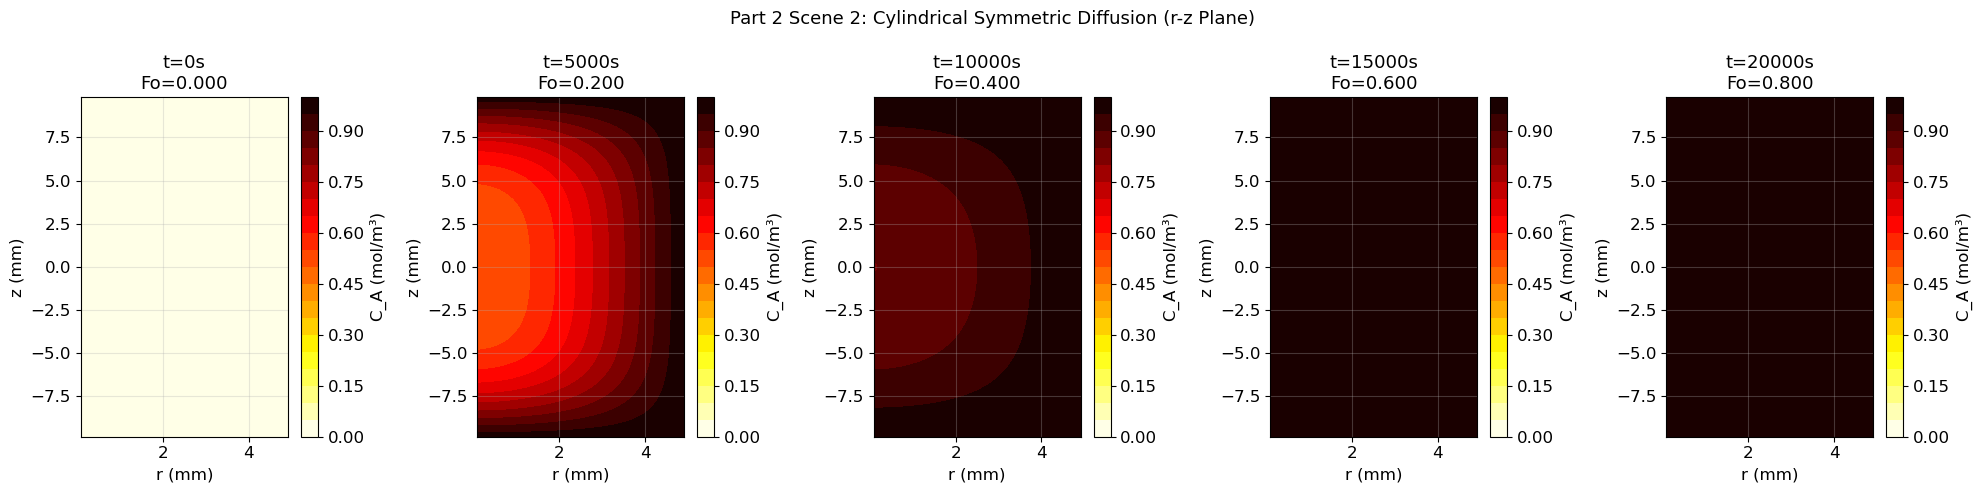

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p2_s2_cylindrical_diffusion.png


In [30]:
# ============================================================
# Part 2 場景二：圓柱座標 2D 軸對稱擴散 (CylindricalSymGrid)
# ============================================================

# ---- 物理參數 ----
D_cyl = 1e-9   # 擴散係數 (m²/s)
R_cyl = 0.005  # 圓柱半徑 R (m) = 5 mm
H_cyl = 0.010  # 圓柱半長 H (m) = 10 mm → 全長 2H = 20 mm
C_A0c = 1.0    # 表面濃度 (mol/m³)
T_cyl = 2e4    # 總模擬時間 (s)
Nr_c, Nz_c = 30, 60  # r 方向、z 方向網格數

# ---- py-pde CylindricalSymGrid ----
# CylindricalSymGrid(radius, bounds_z, shape)
grid_cyl = pde.CylindricalSymGrid(R_cyl, (-H_cyl, H_cyl), (Nr_c, Nz_c))

ic_cyl = pde.ScalarField(grid_cyl, data=0.0)  # 初始無溶質

# 邊界條件: r=R (外壁) Dirichlet C_A0; z=±H (端面) Dirichlet C_A0
# CylindricalSymGrid: 第一組對應 r 方向 (r=R 外壁)
#                     第二組對應 z 方向 [z=-H, z=+H]
bc_cyl = [{"value": C_A0c},        # r=R 外壁
          [{"value": C_A0c}, {"value": C_A0c}]]  # z=-H 和 z=+H 端面

# ---- 估算穩定時步 (顯式, CFL) ----
dr = R_cyl / Nr_c
dz = (2 * H_cyl) / Nz_c
dt_cyl = 0.4 * min(dr, dz)**2 / (2 * D_cyl)   # 安全係數 0.4
print(f"  dr={dr*1e3:.2f} mm, dz={dz*1e3:.2f} mm, dt_stable={dt_cyl:.1f} s")

eq_cyl = pde.DiffusionPDE(diffusivity=D_cyl, bc=bc_cyl)
storage_cyl = pde.MemoryStorage()
result_cyl = eq_cyl.solve(ic_cyl, t_range=T_cyl, dt=dt_cyl,
                           tracker=[storage_cyl.tracker(T_cyl / 4)])

print("✓ Part 2 場景二：圓柱座標軸對稱擴散求解完成")

# ---- 繪圖：不同時刻的 (r, z) 濃度場 ----
snapshots_cyl = list(storage_cyl.items())
n_c = len(snapshots_cyl)

fig, axes = plt.subplots(1, n_c, figsize=(4 * n_c, 5))
fig.suptitle("Part 2 Scene 2: Cylindrical Symmetric Diffusion (r-z Plane)", fontsize=13)

r_cyl = grid_cyl.axes_coords[0] * 1e3   # mm
z_cyl = grid_cyl.axes_coords[1] * 1e3   # mm
Rc, Zc = np.meshgrid(r_cyl, z_cyl)

vmin, vmax = 0, C_A0c
levels_cyl = np.linspace(vmin, vmax, 21)   # 固定 colorbar 範圍，避免 IC=0 時色階異常
for i, (t_val, field) in enumerate(snapshots_cyl):
    C_cyl = np.clip(field.data.T, vmin, vmax)   # (Nr, Nz) → (Nz, Nr)
    Fo_c  = D_cyl * t_val / R_cyl**2
    cf = axes[i].contourf(Rc, Zc, C_cyl, levels=levels_cyl, cmap='hot_r',
                          vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=axes[i], label="C_A (mol/m³)")
    axes[i].set_xlabel("r (mm)")
    axes[i].set_ylabel("z (mm)")
    axes[i].set_title(f"t={t_val:.0f}s\nFo={Fo_c:.3f}")

plt.tight_layout()
fig.savefig(FIG_DIR / "p2_s2_cylindrical_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p2_s2_cylindrical_diffusion.png'}")

---
### 場景三：2D 反應-擴散系統（Gray-Scott Turing Pattern）

**問題描述：** Gray-Scott 雙成分反應-擴散模型，模擬化學自組織圖案的形成。

**統御方程式：**

$$
\frac{\partial u}{\partial t} = D_u \nabla^2 u - uv^2 + F(1 - u)
$$

$$
\frac{\partial v}{\partial t} = D_v \nabla^2 v + uv^2 - (F + k)v
$$

其中 $u$ 為基質（substrate）、$v$ 為自催化劑（autocatalyst）。本場景使用 `py-pde` 的自訂 `PDEBase` 建立雙場耦合 PDE，探討參數 $F$ 與 $k$ 對圖案型態的影響。

| 圖案 | $F$ | $k$ |
|------|-----|-----|
| 斑點（Spots） | 0.035 | 0.065 |
| 條紋（Stripes） | 0.060 | 0.062 |

  0%|          | 0/2000.0 [00:00<?, ?it/s]

  0%|          | 0/2000.0 [00:00<?, ?it/s]

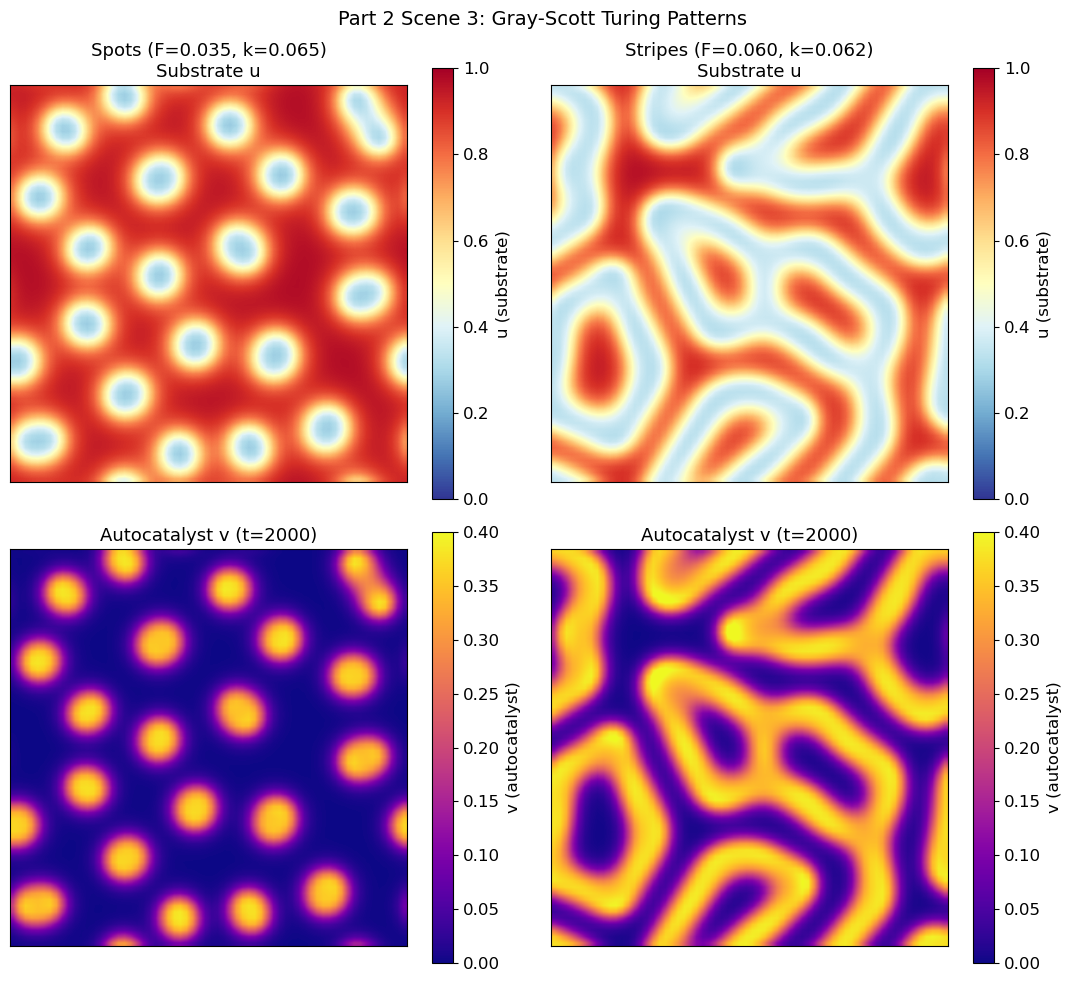

✓ Part 2 場景三：Gray-Scott Turing Pattern 模擬完成
✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p2_s3_gray_scott_turing.png


In [18]:

# ============================================================
# Part 2 場景三：Gray-Scott Turing Pattern (2D 反應-擴散)
# ============================================================
# Gray-Scott 方程（無因次化）：
#   du/dt = Du * ∇²u - u·v² + F·(1-u)
#   dv/dt = Dv * ∇²v + u·v² - (F+k)·v
#
# 使用縮放後的擴散係數 (Du=0.16, Dv=0.08) 以在合理時間內形成可見圖樣

# ---- 自訂 Gray-Scott PDE (繼承 PDEBase) ----
class GrayScottPDE(pde.PDEBase):
    """Gray-Scott dimensional reaction-diffusion PDE"""
    def __init__(self, Du=0.16, Dv=0.08, F=0.035, k=0.065):
        super().__init__()
        self.Du = Du
        self.Dv = Dv
        self.F  = F
        self.k  = k

    def evolution_rate(self, state, t=0):
        u, v = state
        Du, Dv, F, k = self.Du, self.Dv, self.F, self.k
        uvv   = u * v**2
        du_dt = Du * u.laplace(bc="periodic") - uvv + F * (1 - u)
        dv_dt = Dv * v.laplace(bc="periodic") + uvv - (F + k) * v
        return pde.FieldCollection([du_dt, dv_dt])

# ---- 兩組參數：斑點 vs 條紋 ----
param_sets = [
    {"F": 0.035, "k": 0.065, "label": "Spots (F=0.035, k=0.065)"},
    {"F": 0.060, "k": 0.062, "label": "Stripes (F=0.060, k=0.062)"},
]

N_gs = 64    # 網格大小 (64×64)
T_gs = 2000  # 模擬時間（無因次）

# UnitGrid: spacing=1, domain=[0, N_gs]
grid_gs = pde.UnitGrid([N_gs, N_gs], periodic=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
fig.suptitle("Part 2 Scene 3: Gray-Scott Turing Patterns", fontsize=14)

for col, params in enumerate(param_sets):
    gs_eq = GrayScottPDE(Du=0.16, Dv=0.08, F=params["F"], k=params["k"])

    # 初始條件：均勻 u≈1, v≈0，加入隨機擾動以觸發 Turing 不穩定性
    rng    = np.random.default_rng(42 + col)
    u_data = 1.0 - 0.02 * rng.random((N_gs, N_gs))
    v_data = 0.02 * rng.random((N_gs, N_gs))

    # 在隨機位置加入 "種子點"（高 v 擾動）
    n_seeds = 30
    seed_x = rng.integers(5, N_gs-5, size=n_seeds)
    seed_y = rng.integers(5, N_gs-5, size=n_seeds)
    xx, yy = np.meshgrid(np.arange(N_gs), np.arange(N_gs), indexing='ij')
    for sx, sy in zip(seed_x, seed_y):
        dist2 = (xx - sx)**2 + (yy - sy)**2
        v_data += 0.25 * np.exp(-dist2 / 4.0)    # sigma≈2格
    u_data -= v_data * 0.5
    u_data  = np.clip(u_data, 0, 1)
    v_data  = np.clip(v_data, 0, 1)

    u_field = pde.ScalarField(grid_gs, data=u_data)
    v_field = pde.ScalarField(grid_gs, data=v_data)
    state   = pde.FieldCollection([u_field, v_field])

    result_gs = gs_eq.solve(state, t_range=T_gs, dt=0.5)

    u_final = result_gs[0].data
    v_final = result_gs[1].data

    im0 = axes[0, col].imshow(u_final, cmap='RdYlBu_r', interpolation='bilinear',
                               origin='lower', vmin=0, vmax=1)
    plt.colorbar(im0, ax=axes[0, col], label="u (substrate)")
    axes[0, col].set_title(f"{params['label']}\nSubstrate u")
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    im1 = axes[1, col].imshow(v_final, cmap='plasma', interpolation='bilinear',
                               origin='lower', vmin=0, vmax=0.4)
    plt.colorbar(im1, ax=axes[1, col], label="v (autocatalyst)")
    axes[1, col].set_title(f"Autocatalyst v (t={T_gs})")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.tight_layout()
fig.savefig(FIG_DIR / "p2_s3_gray_scott_turing.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Part 2 場景三：Gray-Scott Turing Pattern 模擬完成")
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p2_s3_gray_scott_turing.png'}")


---
## Part 3：三維 (3D) 擴散問題

### 場景一：3D 直角座標箱體中的非穩態擴散

**問題描述：** 立方體箱體（ $x, y, z \in [0, L]$ ），初始均勻濃度，各面施加不同邊界條件，求三維濃度場的演變。

**統御方程式：**

$$
\frac{\partial C_A}{\partial t} = D_{AB} \left(\frac{\partial^2 C_A}{\partial x^2} + \frac{\partial^2 C_A}{\partial y^2} + \frac{\partial^2 C_A}{\partial z^2}\right)
$$

**計算量注意：** 3D 問題的網格點數為 $N^3$ ，建議使用 $20 \sim 30$ 節點以控制計算時間。可視化使用中心截面切片圖。

  N_3d=20, dx=0.50 mm, dt_stable=16.7 s


  0%|          | 0/10000.0 [00:00<?, ?it/s]

✓ Part 3 場景一：3D 箱體擴散求解完成（計算耗時 15.3 秒）


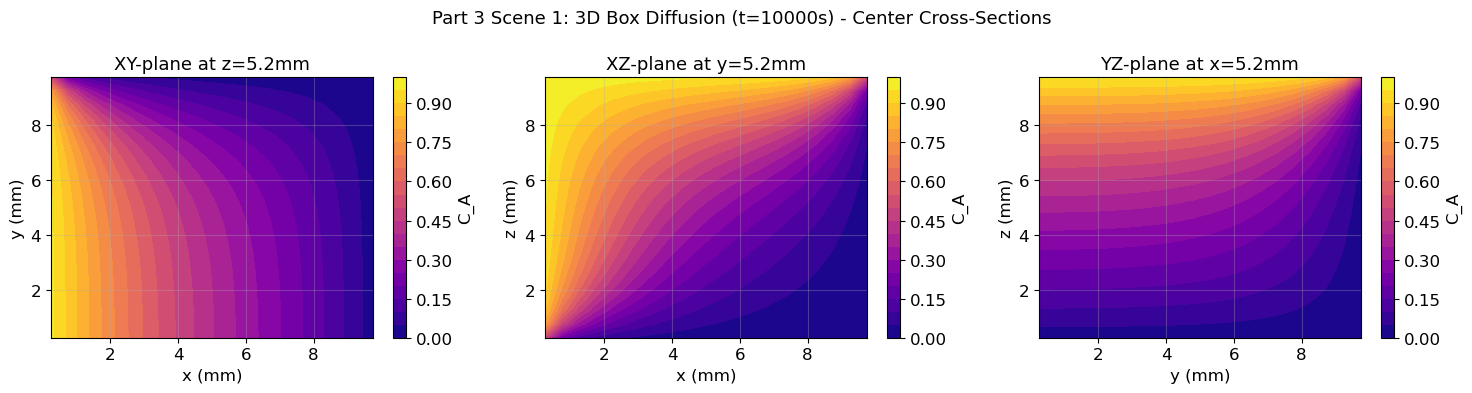

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p3_s1_3d_box_diffusion.png


In [13]:

# ============================================================
# Part 3 場景一：3D 直角座標箱體非穩態擴散
# ============================================================

import time

# ---- 物理參數 ----
D_3d = 1e-9   # 擴散係數 (m²/s)
L_3d = 0.01   # 箱體邊長 (m) = 10 mm
T_3d = 1e4    # 總模擬時間 (s)
N_3d = 20     # 每方向網格節點數 (20³ = 8000 節點，計算量適中)

# ---- py-pde CartesianGrid (3D) ----
grid_3d = pde.CartesianGrid([[0, L_3d]]*3, shape=[N_3d]*3)
ic_3d   = pde.ScalarField(grid_3d, data=0.0)   # 初始零濃度

# 邊界條件:
# x=0(左):C=1; x=L:C=0; y=0(前):無通量; y=L(後):C=0; z=0(底):C=0; z=L(頂):C=1
bc_3d = [
    [{"value": 1.0}, {"value": 0.0}],    # x 方向
    [{"derivative": 0}, {"value": 0.0}], # y 方向
    [{"value": 0.0}, {"value": 1.0}],    # z 方向
]
eq_3d = pde.DiffusionPDE(diffusivity=D_3d, bc=bc_3d)

# ---- 穩定時步 (CFL for 3D explicit solver) ----
dx_3d = L_3d / N_3d
dt_3d = 0.4 * dx_3d**2 / (2 * D_3d * 3)   # 3D CFL: dt ≤ dx²/(2D·ndim)
print(f"  N_3d={N_3d}, dx={dx_3d*1e3:.2f} mm, dt_stable={dt_3d:.1f} s")

t0 = time.time()
result_3d = eq_3d.solve(ic_3d, t_range=T_3d, dt=dt_3d)
t1 = time.time()
print(f"✓ Part 3 場景一：3D 箱體擴散求解完成（計算耗時 {t1-t0:.1f} 秒）")

# ---- 視覺化：三個中心截面切片 ----
C_3d = result_3d.data  # shape: (N, N, N)
mid  = N_3d // 2
x_ax = grid_3d.axes_coords[0] * 1e3  # mm
y_ax = grid_3d.axes_coords[1] * 1e3
z_ax = grid_3d.axes_coords[2] * 1e3

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Part 3 Scene 1: 3D Box Diffusion (t={T_3d:.0f}s) - Center Cross-Sections",
             fontsize=13)

vmin3, vmax3 = 0, 1
# XY 截面 (z = 中心)
X, Y = np.meshgrid(x_ax, y_ax)
cf0 = axes[0].contourf(X, Y, np.clip(C_3d[:, :, mid].T, vmin3, vmax3),
                        levels=20, cmap='plasma', vmin=vmin3, vmax=vmax3)
plt.colorbar(cf0, ax=axes[0], label="C_A")
axes[0].set_xlabel("x (mm)"); axes[0].set_ylabel("y (mm)")
axes[0].set_title(f"XY-plane at z={z_ax[mid]:.1f}mm")

# XZ 截面 (y = 中心)
X, Z = np.meshgrid(x_ax, z_ax)
cf1 = axes[1].contourf(X, Z, np.clip(C_3d[:, mid, :].T, vmin3, vmax3),
                        levels=20, cmap='plasma', vmin=vmin3, vmax=vmax3)
plt.colorbar(cf1, ax=axes[1], label="C_A")
axes[1].set_xlabel("x (mm)"); axes[1].set_ylabel("z (mm)")
axes[1].set_title(f"XZ-plane at y={y_ax[mid]:.1f}mm")

# YZ 截面 (x = 中心)
Y, Z = np.meshgrid(y_ax, z_ax)
cf2 = axes[2].contourf(Y, Z, np.clip(C_3d[mid, :, :].T, vmin3, vmax3),
                        levels=20, cmap='plasma', vmin=vmin3, vmax=vmax3)
plt.colorbar(cf2, ax=axes[2], label="C_A")
axes[2].set_xlabel("y (mm)"); axes[2].set_ylabel("z (mm)")
axes[2].set_title(f"YZ-plane at x={x_ax[mid]:.1f}mm")

plt.tight_layout()
fig.savefig(FIG_DIR / "p3_s1_3d_box_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p3_s1_3d_box_diffusion.png'}")



---
### 場景二：球座標 3D 球體內的非穩態擴散（Diffusion in a Sphere）

**問題描述：** 球形觸媒顆粒（半徑 $R$ ），內部初始無溶質，外表面維持固定濃度 $C_{A0}$ 。

**統御方程式（球座標徑向）：**

$$
\frac{\partial C_A}{\partial t} = D_{AB} \frac{1}{r^2} \frac{\partial}{\partial r}\!\left(r^2 \frac{\partial C_A}{\partial r}\right)
$$

**解析解（Crank, 1975）：**

$$
\frac{C_A - C_{A,i}}{C_{A0} - C_{A,i}} = 1 - \frac{6}{\pi^2} \sum_{n=1}^{\infty} \frac{1}{n^2} \exp\!\left(-\frac{n^2 \pi^2 D_{AB} t}{R^2}\right) \quad \text{(平均濃度)}
$$

`py-pde` 的 `SphericalSymGrid` 利用球對稱性，將問題降維至 **1D 徑向問題**，大幅降低計算量。


  N_sph=50, dr=0.10 mm, dt_stable=2.00 s
✓ Part 3 場景二：球體非穩態擴散求解完成


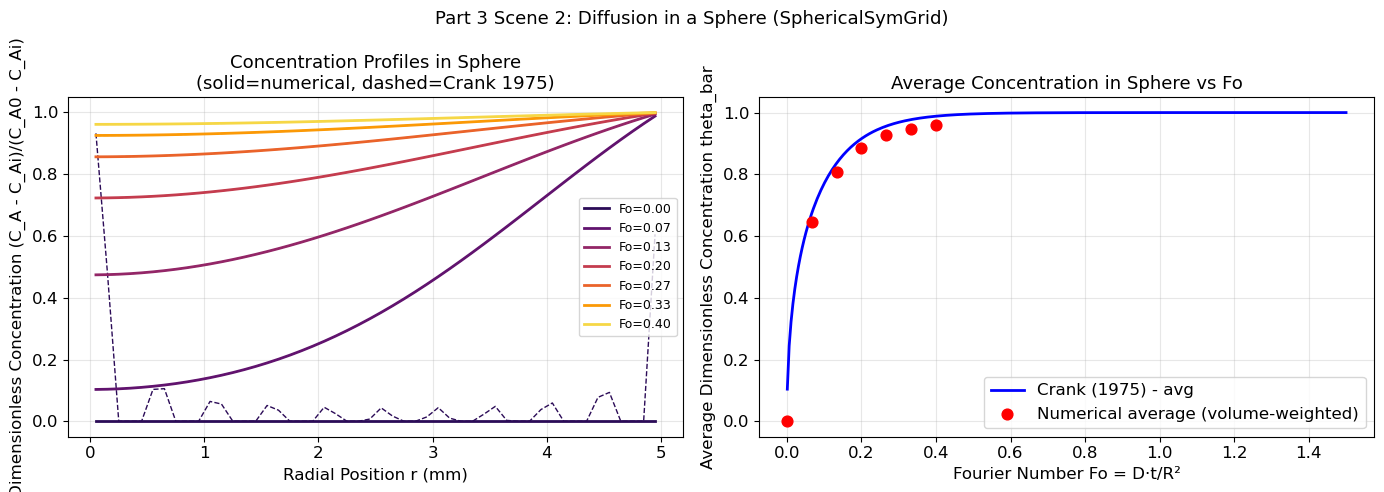

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p3_s2_sphere_diffusion.png


In [14]:

# ============================================================
# Part 3 場景二：球形觸媒顆粒非穩態擴散 (SphericalSymGrid)
# ============================================================

# ---- 物理參數 ----
D_sph = 1e-9   # 擴散係數 (m²/s)
R_sph = 0.005  # 球半徑 (m) = 5 mm
C_Ai_s = 0.0   # 初始濃度
C_A0_s = 1.0   # 表面濃度
T_sph  = 1e4   # 總模擬時間 (s)
N_sph  = 50    # 徑向網格節點數

# ---- Crank (1975) 解析解 (平均濃度) ----
def crank_avg_sphere(Fo, n_terms=50):
    """球體平均無因次濃度 (Crank 1975)"""
    theta_bar = np.zeros_like(Fo, dtype=float)
    for n in range(1, n_terms + 1):
        theta_bar += (1/n**2) * np.exp(-n**2 * np.pi**2 * Fo)
    return 1 - (6 / np.pi**2) * theta_bar

def crank_profile_sphere(r_arr, R, t, D, n_terms=20):
    """球體濃度剖面解析解 (Crank 1975)"""
    theta = np.ones_like(r_arr)
    for n in range(1, n_terms + 1):
        exp_t = np.exp(-n**2 * np.pi**2 * D * t / R**2)
        # 避免 r=0 奇點
        with np.errstate(divide='ignore', invalid='ignore'):
            term = np.where(r_arr > 1e-12,
                            (2*R/(n*np.pi*r_arr)) * (-1)**(n+1) * np.sin(n*np.pi*r_arr/R) * exp_t,
                            0.0)
        theta -= term
    return np.clip(theta, 0, 1)

# ---- py-pde SphericalSymGrid 求解 ----
# 穩定時步 (CFL for 1D explicit solver)
dr_sph  = R_sph / N_sph
dt_sph  = 0.4 * dr_sph**2 / (2 * D_sph)
print(f"  N_sph={N_sph}, dr={dr_sph*1e3:.2f} mm, dt_stable={dt_sph:.2f} s")

grid_sph = pde.SphericalSymGrid(R_sph, N_sph)
ic_sph   = pde.ScalarField(grid_sph, data=C_Ai_s)

# r=0 (球心): 自動對稱; r=R (表面): Dirichlet C_A0
bc_sph = [{"derivative": 0}, {"value": C_A0_s}]
eq_sph = pde.DiffusionPDE(diffusivity=D_sph, bc=bc_sph)
storage_sph = pde.MemoryStorage()

result_sph = eq_sph.solve(ic_sph, t_range=T_sph, dt=dt_sph,
                           tracker=[storage_sph.tracker(T_sph / 6)])

print("✓ Part 3 場景二：球體非穩態擴散求解完成")

# ---- 繪圖 ----
r_sph = grid_sph.axes_coords[0] * 1e3  # mm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 3 Scene 2: Diffusion in a Sphere (SphericalSymGrid)", fontsize=13)

snapshots_s = list(storage_sph.items())
colors_s = plt.cm.inferno(np.linspace(0.15, 0.9, len(snapshots_s)))
for i, (t_val, field) in enumerate(snapshots_s):
    Fo_s  = D_sph * t_val / R_sph**2
    r_ana = grid_sph.axes_coords[0]
    C_ana = crank_profile_sphere(r_ana, R_sph, max(t_val, 1e-6), D_sph)
    axes[0].plot(r_sph, field.data, color=colors_s[i], lw=2,
                 label=f"Fo={Fo_s:.2f}")
    axes[0].plot(r_sph, C_ana, color=colors_s[i], lw=1, ls='--')

axes[0].set_xlabel("Radial Position r (mm)")
axes[0].set_ylabel("Dimensionless Concentration (C_A - C_Ai)/(C_A0 - C_Ai)")
axes[0].set_title("Concentration Profiles in Sphere\n(solid=numerical, dashed=Crank 1975)")
axes[0].legend(fontsize=9)

# 子圖 2：平均濃度 vs Fourier 數
Fo_arr = np.linspace(0.001, 1.5, 300)
theta_avg_ana = crank_avg_sphere(Fo_arr)
axes[1].plot(Fo_arr, theta_avg_ana, 'b-', lw=2, label="Crank (1975) - avg")

Fo_num_s, avg_num_s = [], []
for t_val, field in storage_sph.items():
    Fo_s = D_sph * t_val / R_sph**2
    # 球體體積加權平均：θ̄ = (3/R³) ∫₀ᴿ r² θ(r) dr
    r_arr = grid_sph.axes_coords[0]
    theta_r = field.data
    theta_bar_n = np.trapz(r_arr**2 * theta_r, r_arr) * 3 / R_sph**3
    Fo_num_s.append(Fo_s)
    avg_num_s.append(theta_bar_n)

axes[1].scatter(Fo_num_s, avg_num_s, color='red', s=60, zorder=5,
                label="Numerical average (volume-weighted)")
axes[1].set_xlabel("Fourier Number Fo = D·t/R²")
axes[1].set_ylabel("Average Dimensionless Concentration theta_bar")
axes[1].set_title("Average Concentration in Sphere vs Fo")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "p3_s2_sphere_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存：{FIG_DIR / 'p3_s2_sphere_diffusion.png'}")



---
## Part 4：多成分系統與 Fick 定律的延伸

### 4.1 有效擴散係數 $D_{eff}$ 與觸媒有效因子

在多孔觸媒中，有效擴散係數修正為：

$$
D_{eff} = \frac{\varepsilon_p}{\tau} D_{AB}
$$

球形觸媒的有效因子 $\eta$ 與球形 Thiele 模數 $\phi_s$ 的關係：

$$
\eta = \frac{3}{\phi_s^2}\!\left(\phi_s \coth(\phi_s) - 1\right), \quad \phi_s = R\sqrt{\frac{k_1}{D_{eff}}}
$$

### 4.2 Maxwell-Stefan 擴散

多成分系統（三種以上組分）中，Fick 定律需推廣為 Maxwell-Stefan 方程：

$$
\nabla x_i = \sum_{j \neq i} \frac{x_i N_j - x_j N_i}{c_T D_{ij}}
$$

本節計算球形觸媒有效因子曲線，並展示不同孔隙率/曲折因子對 $D_{eff}$ 的影響。


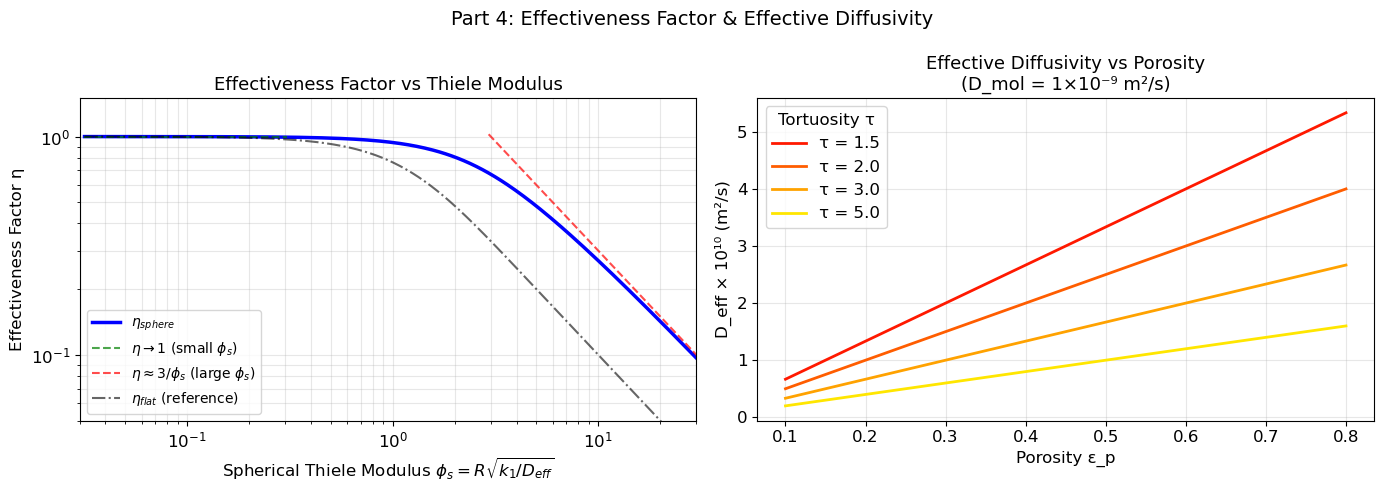


球形觸媒有效因子計算結果（φs = R√(k1/D_eff)）：
      φs |     η_sphere |     η_flat | 建議  
-------------------------------------------------------
     0.1 |       0.9993 |     0.9967 | 擴散可忽略
     0.3 |       0.9941 |     0.9710 | 擴散可忽略
     0.5 |       0.9837 |     0.9242 | 混合控制
     1.0 |       0.9391 |     0.7616 | 混合控制
     2.0 |       0.8060 |     0.4820 | 混合控制
     5.0 |       0.4801 |     0.2000 | 擴散限制
    10.0 |       0.2700 |     0.1000 | 擴散限制

✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_Ficks_Laws_Equation\figs\p4_effectiveness_deff.png


In [16]:

# ============================================================
# Part 4：多成分系統延伸 — 球形觸媒有效因子 & D_eff
# ============================================================

# ---- 4.1 球形觸媒有效因子 vs 球形 Thiele 模數 ----
def eta_sphere(phi_s):
    """球形觸媒有效因子
    Standard Thiele modulus: phi_s = R * sqrt(k1/D_eff)
    eta = (3/phi_s^2) * (phi_s * coth(phi_s) - 1)
    """
    return (3 / phi_s**2) * (phi_s / np.tanh(phi_s) - 1)

phi_s_arr = np.logspace(-1.5, 1.5, 300)
eta_arr_s = eta_sphere(phi_s_arr)

# ---- 4.2 有效擴散係數對孔隙率/曲折因子的敏感性 ----
D_mol = 1e-9    # 分子擴散係數 (m²/s)
eps_range = np.linspace(0.1, 0.8, 50)   # 孔隙率
tau_values = [1.5, 2.0, 3.0, 5.0]      # 曲折因子

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 4: Effectiveness Factor & Effective Diffusivity", fontsize=14)

# 子圖 1：有效因子 η vs 球形 Thiele 模數 φs
axes[0].loglog(phi_s_arr, eta_arr_s, 'b-', lw=2.5, label=r"$\eta_{sphere}$")
axes[0].loglog(phi_s_arr[phi_s_arr < 0.31],
               np.ones(np.sum(phi_s_arr < 0.31)),
               'g--', lw=1.5, alpha=0.7, label=r"$\eta \to 1$ (small $\phi_s$)")
axes[0].loglog(phi_s_arr[phi_s_arr > 2.9],
               3 / phi_s_arr[phi_s_arr > 2.9],
               'r--', lw=1.5, alpha=0.7, label=r"$\eta \approx 3/\phi_s$ (large $\phi_s$)")

# 對比平板觸媒
eta_flat_arr = np.tanh(phi_s_arr) / phi_s_arr
axes[0].loglog(phi_s_arr, eta_flat_arr, 'k-.', lw=1.5, alpha=0.6,
               label=r"$\eta_{flat}$ (reference)")

axes[0].set_xlabel(r"Spherical Thiele Modulus $\phi_s = R\sqrt{k_1/D_{eff}}$")
axes[0].set_ylabel("Effectiveness Factor η")
axes[0].set_title("Effectiveness Factor vs Thiele Modulus")
axes[0].legend(fontsize=10)
axes[0].grid(True, which='both', alpha=0.3)
axes[0].set_xlim([0.03, 30])
axes[0].set_ylim([0.05, 1.5])

# 子圖 2：有效擴散係數 Deff vs 孔隙率 (不同曲折因子)
colors_tau = plt.cm.autumn(np.linspace(0.1, 0.9, len(tau_values)))
for j, tau in enumerate(tau_values):
    D_eff_arr = (eps_range / tau) * D_mol
    axes[1].plot(eps_range, D_eff_arr * 1e10, color=colors_tau[j],
                 lw=2, label=f"τ = {tau}")

axes[1].set_xlabel("Porosity ε_p")
axes[1].set_ylabel("D_eff × 10¹⁰ (m²/s)")
axes[1].set_title("Effective Diffusivity vs Porosity\n(D_mol = 1×10⁻⁹ m²/s)")
axes[1].legend(title="Tortuosity τ")

plt.tight_layout()
fig.savefig(FIG_DIR / "p4_effectiveness_deff.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- 列印有效因子計算表格 ----
print("\n球形觸媒有效因子計算結果（φs = R√(k1/D_eff)）：")
print(f"{'φs':>8} | {'η_sphere':>12} | {'η_flat':>10} | {'建議'}  ")
print("-" * 55)
for phi_s in [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]:
    eta_s = eta_sphere(phi_s)
    eta_f = np.tanh(phi_s) / phi_s
    remark = "擴散可忽略" if phi_s < 0.5 else ("混合控制" if phi_s < 3 else "擴散限制")
    print(f"  {phi_s:6.1f} | {eta_s:12.4f} | {eta_f:10.4f} | {remark}")

print(f"\n✓ 圖檔已儲存：{FIG_DIR / 'p4_effectiveness_deff.png'}")



---
## 結語：Fick's Laws 求解工具選擇指引

| 問題類型 | 幾何形狀 | 推薦工具 | 理由 |
|---------|---------|---------|------|
| 1D Fick 第二定律 | 任意 | `py-pde` 或 `scipy (MoL)` | 簡單高效，解析解驗證方便 |
| 2D 直角座標非穩態擴散 | 矩形 | `py-pde CartesianGrid` | 自動處理多維 Laplacian |
| 2D 軸對稱擴散 | 圓柱體 | `py-pde CylindricalSymGrid` | 原生支援圓柱座標 |
| 3D 球體擴散（球對稱） | 球形 | `py-pde SphericalSymGrid` | 降維至 1D 徑向問題 |
| 3D 直角座標擴散 | 立方體 | `py-pde CartesianGrid` (3D) | 可行，但計算較耗時 |
| 多成分 Maxwell-Stefan | 任意 | `COMSOL` 質傳模組 | 原生多成分求解器 |
| 複雜幾何 / 多孔介質 | 不規則 | `COMSOL` 3D FEM | 任意幾何，高精度 |

**參考文獻：**
- Crank, J. (1975). *The Mathematics of Diffusion* (2nd ed.). Oxford University Press.
- Bird, R. B., Stewart, W. E., & Lightfoot, E. N. (2007). *Transport Phenomena* (Rev. 2nd ed.). Wiley.
- Zwicker, D. (2020). py-pde: A Python package for solving partial differential equations. *Journal of Open Source Software*, 5(48), 2158.

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit 10 偏微分方程式 (PDE) 數值方法 — Fick's Laws 質量傳遞方程式之數值模擬
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-22

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
